In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split as surprise_train_test_split
from surprise.accuracy import rmse

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

print("CineMatch initialized 🚀")

CineMatch initialized 🚀


In [6]:
movies = pd.read_csv("../data/movies.csv")
ratings = pd.read_csv("../data/ratings.csv")

print("Movies:", movies.shape)
print("Ratings:", ratings.shape)

display(movies.head())
display(ratings.head())

Movies: (9742, 3)
Ratings: (100836, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [10]:
print("MOVIES")
print(movies.info())

print("\nRATINGS")
print(ratings.info())

print("Number of users:", ratings["userId"].nunique())
print("Number of movies:", ratings["movieId"].nunique())
print("Number of ratings:", len(ratings))

print("Rating range:")
print(ratings["rating"].min(), "to", ratings["rating"].max())


MOVIES
<class 'pandas.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  9742 non-null   int64
 1   title    9742 non-null   str  
 2   genres   9742 non-null   str  
dtypes: int64(1), str(2)
memory usage: 626.1 KB
None

RATINGS
<class 'pandas.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None
Number of users: 610
Number of movies: 9724
Number of ratings: 100836
Rating range:
0.5 to 5.0


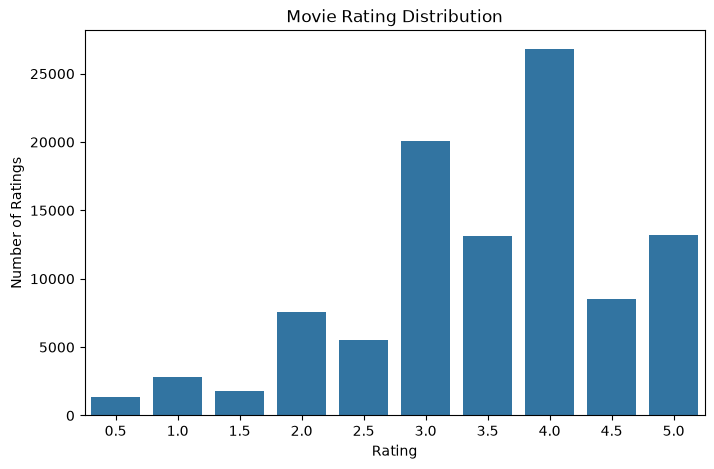

In [11]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=ratings,
    x="rating",
    order=sorted(ratings["rating"].unique())
)

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

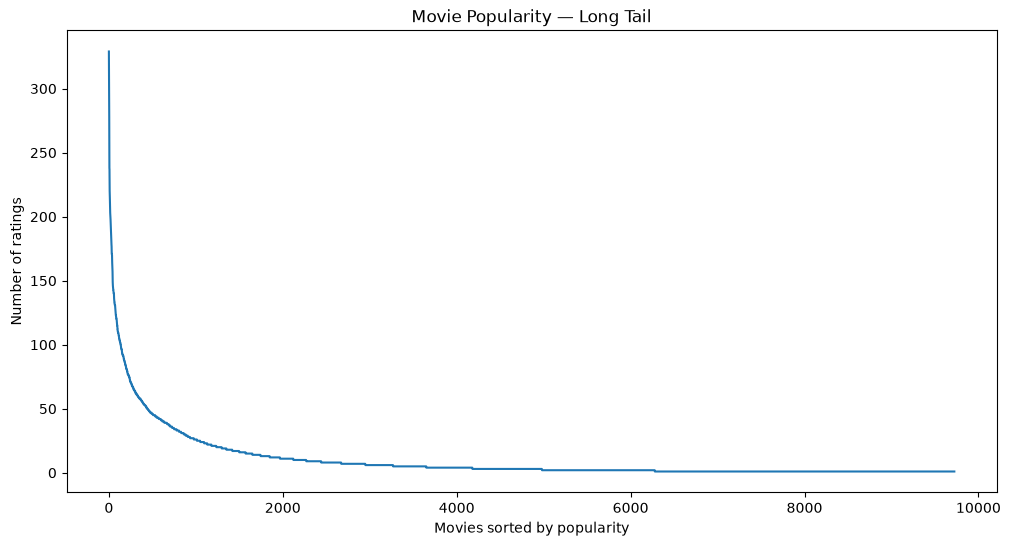

In [14]:
movie_popularity = (
    ratings
    .groupby("movieId")
    .size()
    .reset_index(name="rating_count")
    .merge(movies[["movieId", "title"]], on="movieId")
    .sort_values("rating_count", ascending=False)
)

plt.figure(figsize=(12, 6))

plt.plot(
    movie_popularity["rating_count"].values
)

plt.title("Movie Popularity — Long Tail")
plt.xlabel("Movies sorted by popularity")
plt.ylabel("Number of ratings")

plt.show()

In [16]:
utility_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)
utility_matrix.head()


movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           4.0     NaN     4.0     NaN     NaN     4.0     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           4.0     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  9       10      11      12      13      14      15      16      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  17      18      19      20      21      22      23      24      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     3.0     NaN     NaN     NaN   
5           NaN     NaN     NaN     NaN     4.0     NaN     NaN     NaN   

movieId  25      26      27      28      29      30      31      32      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     0.5     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     2.0   
5           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   

movieId  34      36      38      39      40      41      42      43      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
5           4.0     4.0     NaN     3.0     NaN     NaN     NaN     NaN   

movieId  44      45      46      47      48      49      50      52      \
userId                                                                    
1           NaN     NaN     NaN     5.0     NaN     NaN     5.0     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     3.0     NaN     2.0     NaN     NaN     NaN     3.0   
5           NaN     NaN     NaN     NaN     NaN     NaN     4.0     NaN   

movieId  53      54      55      57      58      60      61      62      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
4           NaN     NaN     NaN     NaN     3.0     NaN     NaN     NaN   
5           NaN     NaN     NaN     NaN     5.0     NaN     NaN     NaN   

movieId  63      64      65      66      68      69      70      71      \
userId                                                                    
1           NaN     NaN     NaN     NaN     NaN     NaN     3.0     NaN   
2           NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
3           NaN   

In [17]:
total_cells = utility_matrix.shape[0] * utility_matrix.shape[1]

filled_cells = utility_matrix.notna().sum().sum()

sparsity = 1 - (filled_cells / total_cells)

print(f"Users: {utility_matrix.shape[0]}")
print(f"Movies: {utility_matrix.shape[1]}")
print(f"Possible ratings: {total_cells:,}")
print(f"Actual ratings: {filled_cells:,}")
print(f"Sparsity: {sparsity:.2%}")

Users: 610
Movies: 9724
Possible ratings: 5,931,640
Actual ratings: 100,836
Sparsity: 98.30%


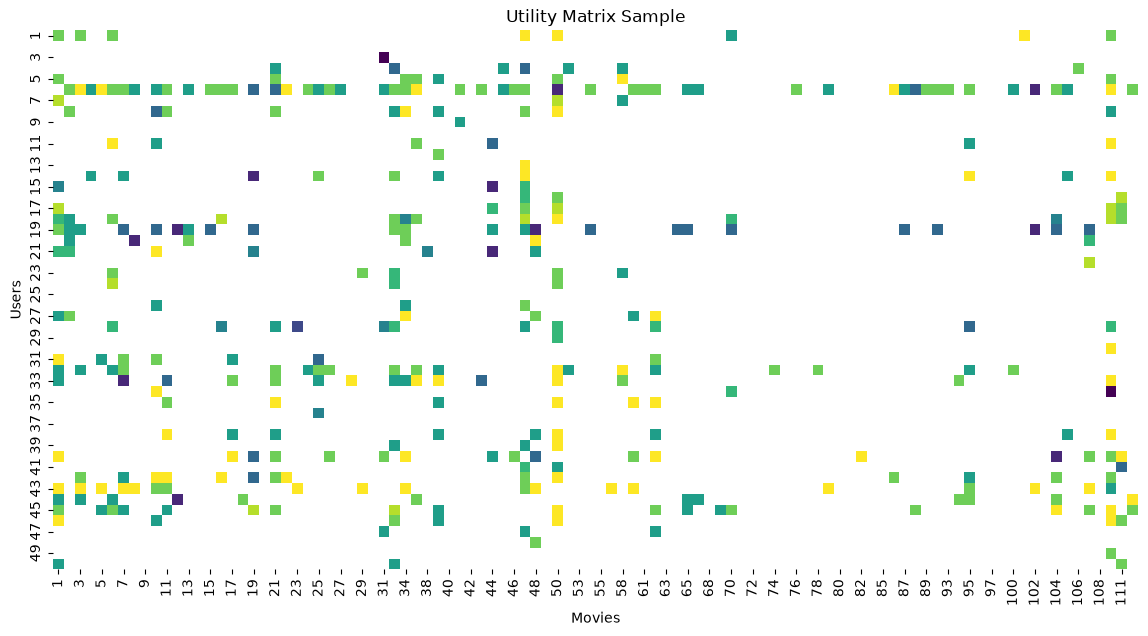

In [18]:
plt.figure(figsize=(14, 7))

sns.heatmap(
    utility_matrix.iloc[:50, :100],
    cmap="viridis",
    cbar=False
)

plt.title("Utility Matrix Sample")
plt.xlabel("Movies")
plt.ylabel("Users")
plt.show()

In [ ]:
target_user = 1

target_vector = utility_matrix.loc[target_user].values

print("Target user:", target_user)
print("Number of ratings:", np.sum(~np.isnan(target_vector)))

user_similarities = {}

for user_id in utility_matrix.index:

    if user_id == target_user:
        continue

    other_vector = utility_matrix.loc[user_id].values

    similarity = cosine_similarity_manual(
        target_vector,
        other_vector
    )

    user_similarities[user_id] = similarity

Target user: 1
Number of ratings: 232


In [30]:
def cosine_similarity_manual(a, b):
    mask = ~np.isnan(a) & ~np.isnan(b)

    a_common = a[mask]
    b_common = b[mask]

    if len(a_common) == 0:
        return 0.0

    denominator = np.linalg.norm(a_common) * np.linalg.norm(b_common)

    if denominator == 0:
        return 0.0

    return np.dot(a_common, b_common) / denominator

similar_users = (
    pd.Series(user_similarities, name="similarity")
    .sort_values(ascending=False)
)

similar_users.head(10) 

top_k_users = similar_users.head(20)

top_k_users


rated_movies = set(
    ratings.loc[
        ratings["userId"] == target_user,
        "movieId"
    ]
)

print("Movies already rated:", len(rated_movies))

candidate_scores = {}

for user_id, similarity in top_k_users.items():

    user_ratings = ratings[
        ratings["userId"] == user_id
    ]

    liked_movies = user_ratings[
        user_ratings["rating"] >= 4
    ]

    for _, row in liked_movies.iterrows():

        movie_id = row["movieId"]

        if movie_id in rated_movies:
            continue

        if movie_id not in candidate_scores:
            candidate_scores[movie_id] = 0

        candidate_scores[movie_id] += similarity * row["rating"]


recommendations = (
    pd.Series(candidate_scores, name="score")
    .sort_values(ascending=False)
)

recommendations.head(10)


recommended_movies = (
    recommendations
    .head(10)
    .reset_index()
    .rename(columns={"index": "movieId"})
    .merge(
        movies[["movieId", "title"]],
        on="movieId"
    )
)

recommended_movies

def recommend_user_based(target_user, n=5, neighbor_count=20):

    # Movies already rated by target user
    rated_movies = set(
        ratings.loc[
            ratings["userId"] == target_user,
            "movieId"
        ]
    )

    # Target vector
    target_vector = utility_matrix.loc[target_user].values

    # Calculate similarity with all users
    similarities = {}

    for user_id in utility_matrix.index:

        if user_id == target_user:
            continue

        other_vector = utility_matrix.loc[user_id].values

        similarities[user_id] = cosine_similarity_manual(
            target_vector,
            other_vector
        )

    # Top neighbors
    top_users = (
        pd.Series(similarities)
        .sort_values(ascending=False)
        .head(neighbor_count)
    )

    # Score candidate movies
    candidate_scores = {}

    for user_id, similarity in top_users.items():

        user_ratings = ratings[
            ratings["userId"] == user_id
        ]

        liked_movies = user_ratings[
            user_ratings["rating"] >= 4
        ]

        for _, row in liked_movies.iterrows():

            movie_id = row["movieId"]

            if movie_id in rated_movies:
                continue

            candidate_scores[movie_id] = (
                candidate_scores.get(movie_id, 0)
                + similarity * row["rating"]
            )

    # Rank
    top_movies = (
        pd.Series(candidate_scores, name="score")
        .sort_values(ascending=False)
        .head(n)
        .reset_index()
        .rename(columns={"index": "movieId"})
    )

    # Add titles
    result = top_movies.merge(
        movies[["movieId", "title"]],
        on="movieId"
    )

    return result

recommend_user_based(1, n=5)

Movies already rated: 232


,movieId,score,title
0,58559.0,36.972458,"Dark Knight, The (2008)"
1,79132.0,31.465510,Inception (2010)
2,109487.0,27.973029,Interstellar (2014)
3,318.0,23.468374,"Shawshank Redemption, The (1994)"
4,7153.0,22.475588,"Lord of the Rings: The Return of the King, The..."


In [23]:
target_user = 1

target_vector = utility_matrix.loc[target_user].values

user_similarities = {}

for user_id in utility_matrix.index:

    if user_id == target_user:
        continue

    other_vector = utility_matrix.loc[user_id].values

    similarity = cosine_similarity_manual(
        target_vector,
        other_vector
    )

    user_similarities[user_id] = similarity


similar_users = (
    pd.Series(user_similarities, name="similarity")
    .sort_values(ascending=False)
)

similar_users.head(10)

358    1.0
383    1.0
388    1.0
85     1.0
77     1.0
253    1.0
315    1.0
291    1.0
184    1.0
245    1.0
Name: similarity, dtype: float64

In [41]:
# Section 11 — Item-Item Collaborative Filtering

# Movies become rows, users become columns
item_matrix = utility_matrix.T

print("Original:", utility_matrix.shape)
print("Item matrix:", item_matrix.shape)

# Replace missing ratings with 0
item_matrix_filled = item_matrix.fillna(0)

# Calculate movie-to-movie cosine similarity
item_similarity_matrix = cosine_similarity(
    item_matrix_filled
)

print("Item similarity matrix:", item_similarity_matrix.shape)

def find_similar_movies(movie_id, n=10):

    if movie_id not in item_matrix.index:
        raise ValueError("Movie not found")

    # Get row position of movie
    movie_index = item_matrix.index.get_loc(movie_id)

    # Similarity scores for this movie
    similarities = item_similarity_matrix[movie_index]

    # Sort highest → lowest
    sorted_indices = np.argsort(similarities)[::-1]

    # Remove the movie itself
    sorted_indices = [
        i for i in sorted_indices
        if item_matrix.index[i] != movie_id
    ]

    # Top N
    top_indices = sorted_indices[:n]

    # Convert positions → movie IDs
    similar_movie_ids = item_matrix.index[top_indices]

    result = pd.DataFrame({
        "movieId": similar_movie_ids,
        "similarity": similarities[top_indices]
    })

    return result.merge(
        movies[["movieId", "title"]],
        on="movieId"
    )

    def search_movie(title):

        return movies[
            movies["title"].str.contains(
            title,
            case=False,
            regex=False
        )
    ][["movieId", "title"]]

def recommend_item_based(
    user_id,
    n=5,
    similar_per_movie=10
):

    # User's ratings
    user_ratings = ratings[
        ratings["userId"] == user_id
    ]

    # Movies user already rated
    already_rated = set(
        user_ratings["movieId"]
    )

    # Movies user liked
    liked_movies = user_ratings[
        user_ratings["rating"] >= 4
    ]

    candidate_scores = {}

    # For every liked movie
    for movie_id in liked_movies["movieId"]:

        similar_movies = find_similar_movies(
            movie_id,
            n=similar_per_movie
        )

        for _, row in similar_movies.iterrows():

            candidate_id = row["movieId"]

            if candidate_id in already_rated:
                continue

            candidate_scores[candidate_id] = (
                candidate_scores.get(candidate_id, 0)
                + row["similarity"]
            )

    # Rank candidates
    recommendations = (
        pd.Series(
            candidate_scores,
            name="score"
        )
        .sort_values(ascending=False)
        .head(n)
        .reset_index()
        .rename(columns={"index": "movieId"})
    )

    return recommendations.merge(
        movies[["movieId", "title"]],
        on="movieId"
    )

find_similar_movies(1, n=10)
def search_movie(title):

    return movies[
        movies["title"].str.contains(
            title,
            case=False,
            regex=False
        )
    ][["movieId", "title"]]

def recommend_item_based(
    user_id,
    n=5,
    similar_per_movie=10
):

    # Get user's ratings
    user_ratings = ratings[
        ratings["userId"] == user_id
    ]

    # Movies already rated by user
    already_rated = set(
        user_ratings["movieId"]
    )

    # Movies the user liked
    liked_movies = user_ratings[
        user_ratings["rating"] >= 4
    ]

    candidate_scores = {}

    # For every movie the user liked
    for movie_id in liked_movies["movieId"]:

        similar_movies = find_similar_movies(
            movie_id,
            n=similar_per_movie
        )

        # Score each similar movie
        for _, row in similar_movies.iterrows():

            candidate_id = row["movieId"]
            similarity = row["similarity"]

            # Don't recommend something
            # the user already rated
            if candidate_id in already_rated:
                continue

            candidate_scores[candidate_id] = (
                candidate_scores.get(candidate_id, 0)
                + similarity
            )

    # Sort candidates
    recommendations = (
        pd.Series(
            candidate_scores,
            name="score"
        )
        .sort_values(
            ascending=False
        )
        .head(n)
        .reset_index()
    )

    # Rename ID column
    recommendations = recommendations.rename(
        columns={"index": "movieId"}
    )

    # Add movie information
    recommendations = recommendations.merge(
        movies[
            ["movieId", "title", "genres"]
        ],
        on="movieId"
    )

    return recommendations

recommend_item_based(1, n=5)

user_1_likes = (
    ratings[
        (ratings["userId"] == 1) &
        (ratings["rating"] >= 4)
    ]
    .merge(
        movies,
        on="movieId"
    )
    .sort_values(
        "rating",
        ascending=False
    )
)

display(
    user_1_likes[
        ["title", "rating"]
    ]
)

Original: (610, 9724)
Item matrix: (9724, 610)
Item similarity matrix: (9724, 9724)


,title,rating
3,Seven (a.k.a. Se7en) (1995),5.0
7,Rob Roy (1995),5.0
5,Bottle Rocket (1996),5.0
4,"Usual Suspects, The (1995)",5.0
11,Dumb & Dumber (Dumb and Dumber) (1994),5.0
...,...,...
186,Predator (1987),4.0
195,Shaft (2000),4.0
194,Big Trouble in Little China (1986),4.0
197,What About Bob? (1991),4.0


In [54]:
# Section 12 — Model-Based Collaborative Filtering

from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

# Surprise expects: user, item, rating

reader = Reader(
    rating_scale=(
        ratings["rating"].min(),
        ratings["rating"].max()
    )
)

data = Dataset.load_from_df(
    ratings[["userId", "movieId", "rating"]],
    reader
)

print("Dataset loaded successfully.")

trainset, testset = train_test_split(
    data,
    test_size=0.2,
    random_state=42
)

print("Training ratings:", trainset.n_ratings)
print("Testing ratings:", len(testset))

svd_model = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)


svd_model.fit(trainset)

print("SVD model trained successfully 🔥")

svd_predictions = svd_model.test(testset)

svd_rmse = accuracy.rmse(
    svd_predictions,
    verbose=True
)

print(f"SVD RMSE: {svd_rmse:.4f}")

user_id = 1
movie_id = 50

prediction = svd_model.predict(
    user_id,
    movie_id
)

print("User:", user_id)
print("Movie:", movie_id)
print("Actual rating:", prediction.r_ui)
print("Predicted rating:", round(prediction.est, 3))

def recommend_movies_svd(user_id, n=5):

    # Movies already rated by the user
    rated_movie_ids = set(
        ratings[
            ratings["userId"] == user_id
        ]["movieId"]
    )

    # Movies the user has NOT rated
    unrated_movies = movies[
        ~movies["movieId"].isin(rated_movie_ids)
    ]

    predictions = []

    # Predict rating for every unseen movie
    for movie_id in unrated_movies["movieId"]:

        prediction = svd_model.predict(
            user_id,
            movie_id
        )

        predictions.append({
            "movieId": movie_id,
            "predicted_rating": prediction.est
        })

    recommendations = (
        pd.DataFrame(predictions)
        .sort_values(
            "predicted_rating",
            ascending=False
        )
        .head(n)
    )

    return recommendations.merge(
        movies[
            ["movieId", "title", "genres"]
        ],
        on="movieId"
    )

user_recommendations = recommend_movies_svd(
    user_id=1,
    n=5
)

user_recommendations


display(
    user_recommendations[
        ["title", "genres", "predicted_rating"]
    ]
)




Dataset loaded successfully.
Training ratings: 80668
Testing ratings: 20168
SVD model trained successfully 🔥
RMSE: 0.8807
SVD RMSE: 0.8807
User: 1
Movie: 50
Actual rating: None
Predicted rating: 5.0


,title,genres,predicted_rating
0,Blade Runner (1982),Action|Sci-Fi|Thriller,5.0
1,"Departed, The (2006)",Crime|Drama|Thriller,5.0
2,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,5.0
3,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,5.0
4,On the Waterfront (1954),Crime|Drama,5.0


In [ ]:
ratings.head()

reader = Reader(
    rating_scale=(
        ratings["rating"].min(),
        ratings["rating"].max()
    )
)

surprise_data = Dataset.load_from_df(
    ratings[
        ["userId", "movieId", "rating"]
    ],
    reader
)



Training ratings: 80668
Testing ratings: 20168


In [43]:
trainset, testset = surprise_train_test_split(
    surprise_data,
    test_size=0.2,
    random_state=42
)

print("Training ratings:", trainset.n_ratings)
print("Testing ratings:", len(testset))

Training ratings: 80668
Testing ratings: 20168


In [45]:
svd_model = SVD(
    n_factors=50,
    n_epochs=20,
    random_state=42
)

svd_model.fit(trainset)

In [46]:
prediction = svd_model.predict(
    uid=1,
    iid=1
)

prediction

prediction = svd_model.predict(
    uid=1,
    iid=1
)
print("Predicted rating:", prediction.est)

svd_model.predict(
    uid=1,
    iid=500
).est

Predicted rating: 4.6345614653033325


np.float64(4.034718313251887)

In [47]:
svd_predictions = svd_model.test(testset)

svd_rmse = rmse(
    svd_predictions,
    verbose=True
)

RMSE: 0.8775


In [48]:
prediction_df = pd.DataFrame(
    [
        {
            "userId": p.uid,
            "movieId": p.iid,
            "actual": p.r_ui,
            "predicted": p.est
        }
        for p in svd_predictions
    ]
)

prediction_df.head(10)

prediction_df["error"] = abs(
    prediction_df["actual"]
    - prediction_df["predicted"]
)

prediction_df.head(10)

,userId,movieId,actual,predicted,error
0,140,6765,3.5,3.381675,0.118325
1,603,290,4.0,3.585833,0.414167
2,438,5055,4.0,3.065738,0.934262
3,433,164179,5.0,3.607901,1.392099
4,474,5114,4.0,3.312712,0.687288
5,304,1035,4.0,4.302657,0.302657
6,298,4974,1.0,2.280020,1.280020
7,131,293,4.0,3.288250,0.711750
8,288,5784,2.5,2.685594,0.185594
9,448,97225,2.5,2.863220,0.363220


In [50]:

def recommend_svd(user_id, n=5):

    rated_movie_ids = set(
        ratings.loc[
            ratings["userId"] == user_id,
            "movieId"
        ]
    )

    candidate_movies = movies[
        ~movies["movieId"].isin(rated_movie_ids)
    ]

    predictions = []

    for movie_id in candidate_movies["movieId"]:

        predicted_rating = svd_model.predict(
            uid=user_id,
            iid=movie_id
        ).est

        predictions.append(
            (movie_id, predicted_rating)
        )

    predictions.sort(
        key=lambda x: x[1],
        reverse=True
    )

    top_predictions = predictions[:n]

    result = pd.DataFrame(
        top_predictions,
        columns=[
            "movieId",
            "predicted_rating"
        ]
    )

    result = result.merge(
        movies[
            ["movieId", "title", "genres"]
        ],
        on="movieId"
    )

    return result

    recommend_svd(1, n=5)

In [52]:
def recommend_movies(user_id, n=5):

    recommendations = recommend_svd(
        user_id,
        n=n
    )

    print(
        f"\n🎬 CineMatch Recommendations "
        f"for User #{user_id}\n"
    )

    for i, row in recommendations.iterrows():

        print(
            f"{i + 1}. {row['title']}"
            f" — predicted {row['predicted_rating']:.2f} ⭐"
        )

    return recommendations

    user_recommendations = recommend_movies(1)

Final visualization section ready 🔥


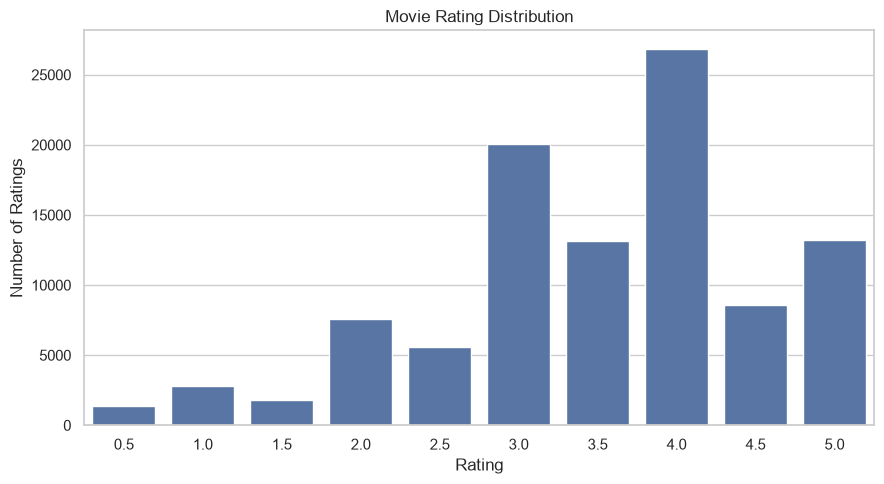

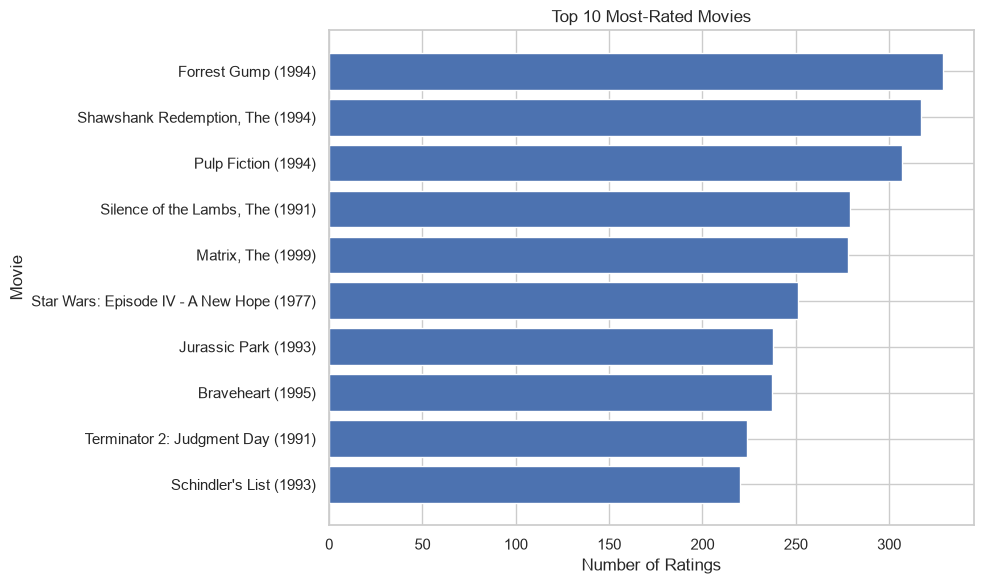

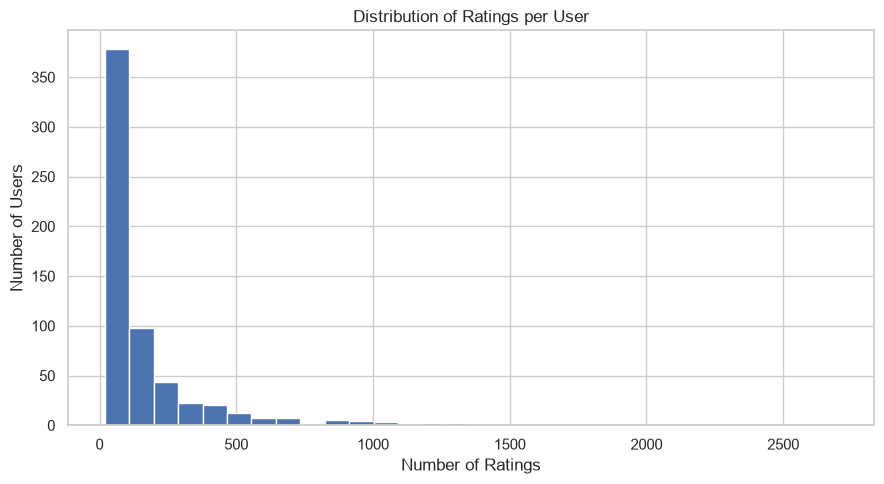

,Model,RMSE
0,SVD,0.880746


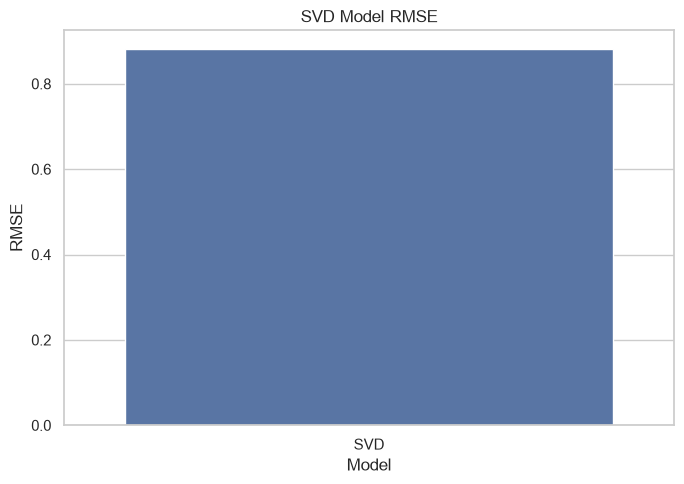

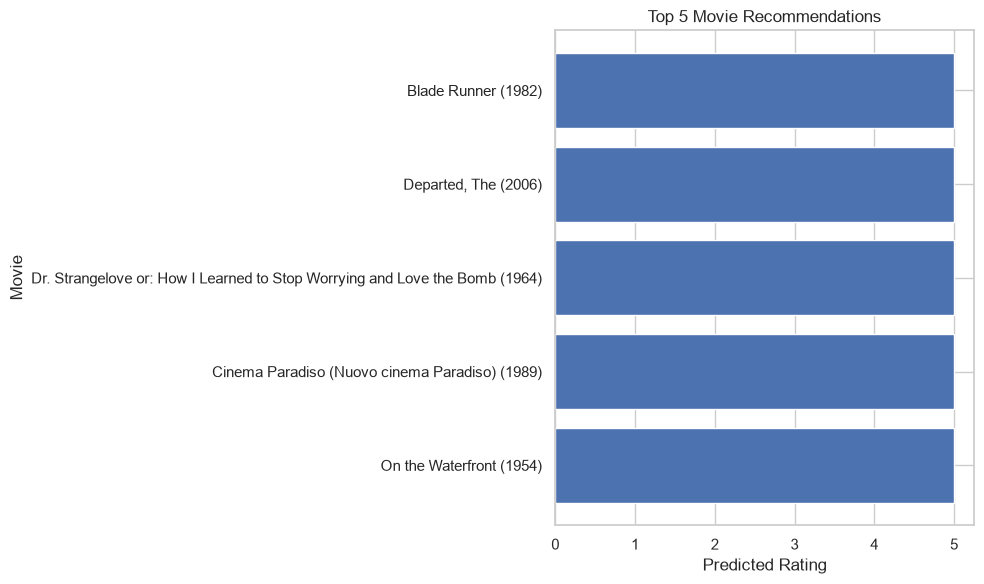

                 CINEMATCH RESULTS

SVD Model Performance:


,Model,RMSE
0,SVD,0.880746



Top 5 Recommendations:


,title,genres,predicted_rating
0,Blade Runner (1982),Action|Sci-Fi|Thriller,5.0
1,"Departed, The (2006)",Crime|Drama|Thriller,5.0
2,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,5.0
3,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,5.0
4,On the Waterfront (1954),Crime|Drama,5.0



SVD Model Performance:


,Model,RMSE
0,SVD,0.880746


In [63]:
# ============================================================
# FINAL SECTION — RESULTS & VISUALIZATIONS
# ============================================================

import os
import matplotlib.pyplot as plt
import seaborn as sns

# Create output directory
os.makedirs("../outputs/plots", exist_ok=True)

sns.set_theme(style="whitegrid")

print("Final visualization section ready 🔥")

plt.figure(figsize=(9, 5))

sns.countplot(
    data=ratings,
    x="rating"
)

plt.title("Movie Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.tight_layout()

plt.savefig(
    "../outputs/plots/rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

top_movies = (
    ratings["movieId"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_movies.columns = [
    "movieId",
    "rating_count"
]

top_movies = top_movies.merge(
    movies[["movieId", "title"]],
    on="movieId"
)

top_movies = top_movies.sort_values(
    "rating_count",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_movies["title"],
    top_movies["rating_count"]
)

plt.title("Top 10 Most-Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")

plt.tight_layout()

plt.savefig(
    "../outputs/plots/top_10_most_rated_movies.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

ratings_per_user = (
    ratings
    .groupby("userId")
    .size()
)

plt.figure(figsize=(9, 5))

plt.hist(
    ratings_per_user,
    bins=30
)

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.tight_layout()

plt.savefig(
    "../outputs/plots/ratings_per_user.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# SVD RMSE result

svd_results = pd.DataFrame({
    "Model": ["SVD"],
    "RMSE": [svd_rmse]
})

display(svd_results)

plt.figure(figsize=(7, 5))

sns.barplot(
    data=svd_results,
    x="Model",
    y="RMSE"
)

plt.title("SVD Model RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.tight_layout()

plt.savefig(
    "../outputs/plots/svd_rmse.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


recommendation_plot = user_recommendations.copy()

plt.figure(figsize=(10, 6))

plt.barh(
    recommendation_plot["title"].iloc[::-1],
    recommendation_plot["predicted_rating"].iloc[::-1]
)

plt.title("Top 5 Movie Recommendations")
plt.xlabel("Predicted Rating")
plt.ylabel("Movie")

plt.tight_layout()

plt.savefig(
    "../outputs/plots/top_5_recommendations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("=" * 60)
print("                 CINEMATCH RESULTS")
print("=" * 60)



print("\nSVD Model Performance:")

svd_results = pd.DataFrame({
    "Model": ["SVD"],
    "RMSE": [svd_rmse]
})

display(svd_results)

print("\nTop 5 Recommendations:")
display(
    user_recommendations[
        ["title", "genres", "predicted_rating"]
    ]
)

print("\nSVD Model Performance:")

svd_results = pd.DataFrame({
    "Model": ["SVD"],
    "RMSE": [svd_rmse]
})

display(svd_results)

Starting final evaluation...
Training ratings: 80,668
Testing ratings:  20,168
Utility matrix: (610, 8983)

[1/3] Evaluating User-Based CF...
User-Based CF RMSE: 0.9684

[2/3] Evaluating Item-Based CF...
Item-Based CF RMSE: 1.1946

[3/3] Evaluating SVD...
SVD RMSE: 0.8831

         CINEMATCH FINAL MODEL EVALUATION


,Model,RMSE
0,SVD,0.883105
1,User-Based CF,0.968408
2,Item-Based CF,1.194641


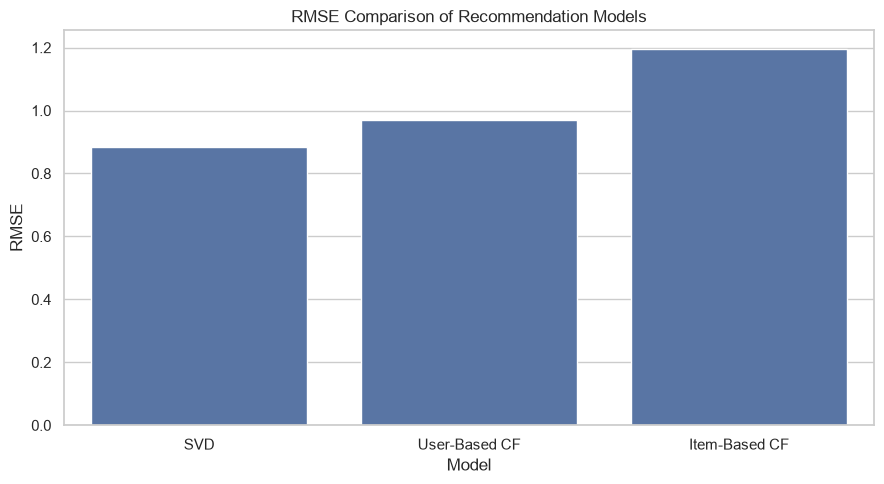


Evaluation complete.
Results saved to ../outputs/results/model_evaluation.csv


In [67]:
# ============================================================
# SECTION 21 — FINAL MODEL EVALUATION
# User-Based CF vs Item-Based CF vs SVD
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity

from surprise import Dataset, Reader, SVD


# ------------------------------------------------------------
# 21.1 Setup
# ------------------------------------------------------------

os.makedirs("../outputs/plots", exist_ok=True)
os.makedirs("../outputs/results", exist_ok=True)

print("Starting final evaluation...")


# ------------------------------------------------------------
# 21.2 Common train/test split
# ------------------------------------------------------------

train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.20,
    random_state=42
)

train_ratings = train_ratings.reset_index(drop=True)
test_ratings = test_ratings.reset_index(drop=True)

print(f"Training ratings: {len(train_ratings):,}")
print(f"Testing ratings:  {len(test_ratings):,}")


# ------------------------------------------------------------
# 21.3 Build training utility matrix
# ------------------------------------------------------------

train_user_matrix = train_ratings.pivot(
    index="userId",
    columns="movieId",
    values="rating"
)

train_user_filled = (
    train_user_matrix
    .fillna(0)
    .astype(np.float32)
)

global_mean = train_ratings["rating"].mean()

user_means = (
    train_ratings
    .groupby("userId")["rating"]
    .mean()
)

print("Utility matrix:", train_user_matrix.shape)


# ============================================================
# 21.4 USER-BASED COLLABORATIVE FILTERING
# ============================================================

print("\n[1/3] Evaluating User-Based CF...")

# User-user cosine similarity
user_similarity = cosine_similarity(
    train_user_filled
)

user_ids = train_user_matrix.index.to_list()

user_to_index = {
    user_id: i
    for i, user_id in enumerate(user_ids)
}


# Precompute which users rated each movie
movie_raters = defaultdict(list)

for user_id, movie_id, rating in train_ratings[
    ["userId", "movieId", "rating"]
].itertuples(index=False, name=None):

    movie_raters[movie_id].append(
        (user_to_index[user_id], rating)
    )


user_predictions = []

for row in test_ratings.itertuples(index=False):

    user_id = row.userId
    movie_id = row.movieId

    # Cold-start fallback
    if user_id not in user_to_index:

        prediction = global_mean

    else:

        user_index = user_to_index[user_id]

        raters = movie_raters.get(
            movie_id,
            []
        )

        neighbors = []

        for other_index, rating in raters:

            if other_index == user_index:
                continue

            similarity = user_similarity[
                user_index,
                other_index
            ]

            if similarity > 0:

                neighbors.append(
                    (similarity, rating)
                )

        if not neighbors:

            prediction = user_means.get(
                user_id,
                global_mean
            )

        else:

            neighbors.sort(
                key=lambda x: x[0],
                reverse=True
            )

            neighbors = neighbors[:20]

            numerator = sum(
                similarity * rating
                for similarity, rating
                in neighbors
            )

            denominator = sum(
                similarity
                for similarity, _
                in neighbors
            )

            if denominator == 0:

                prediction = user_means.get(
                    user_id,
                    global_mean
                )

            else:

                prediction = (
                    numerator / denominator
                )

    user_predictions.append(prediction)


user_actual = test_ratings["rating"].to_numpy()

user_rmse = np.sqrt(
    np.mean(
        (
            user_actual
            - np.array(user_predictions)
        ) ** 2
    )
)

print(
    f"User-Based CF RMSE: "
    f"{user_rmse:.4f}"
)


# ============================================================
# 21.5 ITEM-BASED COLLABORATIVE FILTERING
# ============================================================

print("\n[2/3] Evaluating Item-Based CF...")

# Movie x User matrix
train_item_matrix = (
    train_user_filled
    .T
)

item_ids = train_item_matrix.index.to_list()

item_to_index = {
    movie_id: i
    for i, movie_id in enumerate(item_ids)
}


# Normalize item vectors
item_vectors = train_item_matrix.to_numpy(
    dtype=np.float32
)

item_norms = np.linalg.norm(
    item_vectors,
    axis=1,
    keepdims=True
)

item_norms[item_norms == 0] = 1

item_vectors_normalized = (
    item_vectors / item_norms
)


# Precompute each user's training history
user_history = defaultdict(dict)

for user_id, movie_id, rating in train_ratings[
    ["userId", "movieId", "rating"]
].itertuples(index=False, name=None):

    user_history[user_id][movie_id] = rating


item_predictions = []

# Group test ratings by user
for user_id, user_test_rows in test_ratings.groupby(
    "userId"
):

    history = user_history.get(
        user_id,
        {}
    )

    rated_movie_ids = [
        movie_id
        for movie_id in history
        if movie_id in item_to_index
    ]

    if not rated_movie_ids:

        for _ in range(len(user_test_rows)):
            item_predictions.append(
                global_mean
            )

        continue

    rated_indices = np.array([
        item_to_index[movie_id]
        for movie_id in rated_movie_ids
    ])

    rated_ratings = np.array([
        history[movie_id]
        for movie_id in rated_movie_ids
    ])

    rated_vectors = (
        item_vectors_normalized[
            rated_indices
        ]
    )

    for row in user_test_rows.itertuples(
        index=False
    ):

        movie_id = row.movieId

        # Movie never appeared in training
        if movie_id not in item_to_index:

            prediction = user_means.get(
                user_id,
                global_mean
            )

            item_predictions.append(
                prediction
            )

            continue

        target_index = item_to_index[
            movie_id
        ]

        target_vector = (
            item_vectors_normalized[
                target_index
            ]
        )

        # Similarity against this user's
        # previously rated movies
        similarities = (
            rated_vectors
            @ target_vector
        )

        positive_mask = similarities > 0

        if not positive_mask.any():

            prediction = user_means.get(
                user_id,
                global_mean
            )

            item_predictions.append(
                prediction
            )

            continue

        similarities = similarities[
            positive_mask
        ]

        ratings_for_neighbors = (
            rated_ratings[
                positive_mask
            ]
        )

        # Keep strongest 20 neighbors
        if len(similarities) > 20:

            top_indices = np.argpartition(
                similarities,
                -20
            )[-20:]

            similarities = similarities[
                top_indices
            ]

            ratings_for_neighbors = (
                ratings_for_neighbors[
                    top_indices
                ]
            )

        denominator = similarities.sum()

        if denominator == 0:

            prediction = user_means.get(
                user_id,
                global_mean
            )

        else:

            prediction = (
                np.sum(
                    similarities
                    * ratings_for_neighbors
                )
                / denominator
            )

        item_predictions.append(
            prediction
        )


item_actual = test_ratings["rating"].to_numpy()

item_rmse = np.sqrt(
    np.mean(
        (
            item_actual
            - np.array(item_predictions)
        ) ** 2
    )
)

print(
    f"Item-Based CF RMSE: "
    f"{item_rmse:.4f}"
)


# ============================================================
# 21.6 SVD
# ============================================================

print("\n[3/3] Evaluating SVD...")


reader = Reader(
    rating_scale=(
        ratings["rating"].min(),
        ratings["rating"].max()
    )
)

train_data = Dataset.load_from_df(
    train_ratings[
        ["userId", "movieId", "rating"]
    ],
    reader
)

svd_trainset = (
    train_data
    .build_full_trainset()
)


svd_model_final = SVD(
    n_factors=100,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.02,
    random_state=42
)

svd_model_final.fit(
    svd_trainset
)


svd_testset = [
    (
        row.userId,
        row.movieId,
        row.rating
    )
    for row in test_ratings.itertuples(
        index=False
    )
]


svd_predictions = (
    svd_model_final
    .test(svd_testset)
)


svd_actual = np.array([
    prediction.r_ui
    for prediction in svd_predictions
])

svd_estimated = np.array([
    prediction.est
    for prediction in svd_predictions
])


svd_rmse_final = np.sqrt(
    np.mean(
        (
            svd_actual
            - svd_estimated
        ) ** 2
    )
)

print(
    f"SVD RMSE: "
    f"{svd_rmse_final:.4f}"
)


# ============================================================
# 21.7 FINAL COMPARISON
# ============================================================

evaluation_results = pd.DataFrame({

    "Model": [
        "User-Based CF",
        "Item-Based CF",
        "SVD"
    ],

    "RMSE": [
        user_rmse,
        item_rmse,
        svd_rmse_final
    ]

})

evaluation_results = (
    evaluation_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)


print("\n" + "=" * 60)
print("         CINEMATCH FINAL MODEL EVALUATION")
print("=" * 60)

display(evaluation_results)


# Save results
evaluation_results.to_csv(
    "../outputs/results/model_evaluation.csv",
    index=False
)


# ============================================================
# 21.8 RMSE GRAPH
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=evaluation_results,
    x="Model",
    y="RMSE"
)

plt.title(
    "RMSE Comparison of Recommendation Models"
)

plt.xlabel("Model")
plt.ylabel("RMSE")

plt.tight_layout()

plt.savefig(
    "../outputs/plots/rmse_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\nEvaluation complete.")
print(
    "Results saved to "
    "../outputs/results/model_evaluation.csv"
)

In [68]:
# ============================================================
# SECTION 22 — GENERATE FINAL EVALUATION REPORT
# ============================================================

evaluation_report = evaluation_results.copy()

# Best RMSE model
best_model = evaluation_report.iloc[0]["Model"]
best_rmse = evaluation_report.iloc[0]["RMSE"]

report_text = f"""
# CineMatch — Evaluation Report

## Objective

CineMatch compares three collaborative filtering approaches:

1. User-Based Collaborative Filtering
2. Item-Based Collaborative Filtering
3. Singular Value Decomposition (SVD)

The models are evaluated using Root Mean Squared Error (RMSE).

## Evaluation Setup

The dataset was divided into:

- 80% training data
- 20% testing data
- Random state: 42

The same train/test split was used for all three approaches.

## RMSE Results

| Model | RMSE |
|---|---:|
"""

for _, row in evaluation_report.iterrows():
    report_text += (
        f"| {row['Model']} | "
        f"{row['RMSE']:.4f} |\n"
    )

report_text += f"""

## Result

The model with the lowest RMSE in this experiment was:

**{best_model}**

with an RMSE of **{best_rmse:.4f}**.

## Interpretation

RMSE measures the difference between predicted and actual ratings.
A lower RMSE indicates smaller prediction error on the evaluated test set.

## Conclusion

CineMatch demonstrates three approaches to collaborative filtering:

- User-User similarity
- Item-Item similarity
- Matrix Factorization using SVD

The comparison provides a quantitative view of their rating-prediction performance on the MovieLens dataset.
"""

report_path = "../outputs/results/evaluation_report.md"

with open(
    report_path,
    "w",
    encoding="utf-8"
) as file:
    file.write(report_text)

print("Evaluation report saved:")
print(report_path)

print("\n" + report_text)

Evaluation report saved:
../outputs/results/evaluation_report.md


# CineMatch — Evaluation Report

## Objective

CineMatch compares three collaborative filtering approaches:

1. User-Based Collaborative Filtering
2. Item-Based Collaborative Filtering
3. Singular Value Decomposition (SVD)

The models are evaluated using Root Mean Squared Error (RMSE).

## Evaluation Setup

The dataset was divided into:

- 80% training data
- 20% testing data
- Random state: 42

The same train/test split was used for all three approaches.

## RMSE Results

| Model | RMSE |
|---|---:|
| SVD | 0.8831 |
| User-Based CF | 0.9684 |
| Item-Based CF | 1.1946 |


## Result

The model with the lowest RMSE in this experiment was:

**SVD**

with an RMSE of **0.8831**.

## Interpretation

RMSE measures the difference between predicted and actual ratings.
A lower RMSE indicates smaller prediction error on the evaluated test set.

## Conclusion

CineMatch demonstrates three approaches to collaborative filtering:

- U

In [69]:
# ============================================================
# SECTION 23 — DEMO OUTPUT
# ============================================================

demo_user = 1

demo_recommendations = user_recommendations.copy()

print("=" * 60)
print(f"CINEMATCH DEMO — USER #{demo_user}")
print("=" * 60)

print("\nTop 5 Recommended Movies:\n")

display(
    demo_recommendations[
        [
            "title",
            "genres",
            "predicted_rating"
        ]
    ]
)

demo_text = "=" * 60 + "\n"
demo_text += f"CINEMATCH DEMO — USER #{demo_user}\n"
demo_text += "=" * 60 + "\n\n"
demo_text += "Top 5 Recommended Movies:\n\n"

for i, (_, row) in enumerate(
    demo_recommendations.iterrows(),
    start=1
):

    demo_text += (
        f"{i}. {row['title']} | "
        f"{row['genres']} | "
        f"Predicted Rating: "
        f"{row['predicted_rating']:.3f}\n"
    )

demo_path = "../outputs/results/demo_output.txt"

with open(
    demo_path,
    "w",
    encoding="utf-8"
) as file:
    file.write(demo_text)

print("\nDemo output saved:")
print(demo_path)

CINEMATCH DEMO — USER #1

Top 5 Recommended Movies:



,title,genres,predicted_rating
0,Blade Runner (1982),Action|Sci-Fi|Thriller,5.0
1,"Departed, The (2006)",Crime|Drama|Thriller,5.0
2,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,5.0
3,Cinema Paradiso (Nuovo cinema Paradiso) (1989),Drama,5.0
4,On the Waterfront (1954),Crime|Drama,5.0



Demo output saved:
../outputs/results/demo_output.txt
